In [1]:
# Install necessary libraries silently
!pip -q install datasets scikit-learn

In [2]:
# Import essential libraries for numerical operations and plotting
import numpy as np
import matplotlib.pyplot as plt

# Import the datasets library from Hugging Face for easy data loading
from datasets import load_dataset

# Import TensorFlow and Keras components for building and training the model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Import scikit-learn metrics for model evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set a random seed for reproducibility across runs
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
# Load the Fashion-MNIST dataset using the Hugging Face datasets library
ds = load_dataset("fashion_mnist")
# Display the dataset structure (DatasetDict with train and test splits)
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
# Split the training dataset into training and validation sets (90% train, 10% validation)
split = ds["train"].train_test_split(test_size=0.1, seed=SEED)
# Assign the splits to respective variables
train_ds = split["train"]
val_ds   = split["test"]
# Use the original test set as the final test dataset
test_ds   = ds["test"]

# Display the resulting datasets and their sizes
train_ds, val_ds, test_ds

(Dataset({
     features: ['image', 'label'],
     num_rows: 54000
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 6000
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 10000
 }))

In [5]:
# Define the class names for the Fashion-MNIST dataset
class_names = [
    "T-shirt/top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

# Define a function to convert Hugging Face dataset format to NumPy arrays
def hf_to_numpy(hf_ds):
    # Stack image data into a NumPy array and convert to float32
    X = np.stack([np.array(img) for img in hf_ds["image"]]).astype("float32")
    # Convert labels to int64 NumPy array
    y = np.array(hf_ds["label"]).astype("int64")
    return X, y

# Convert the training, validation, and test datasets to NumPy arrays
X_train, y_train = hf_to_numpy(train_ds)
X_val,   y_val   = hf_to_numpy(val_ds)
X_test,  y_test  = hf_to_numpy(test_ds)

# Normalize pixel values from [0, 255] to [0, 1] and add a channel dimension
X_train = (X_train / 255.0)[..., None]
X_val   = (X_val   / 255.0)[..., None]
X_test  = (X_test  / 255.0)[..., None]

# Print the shape of the training features and labels to verify
X_train.shape, y_train.shape

((54000, 28, 28, 1), (54000,))

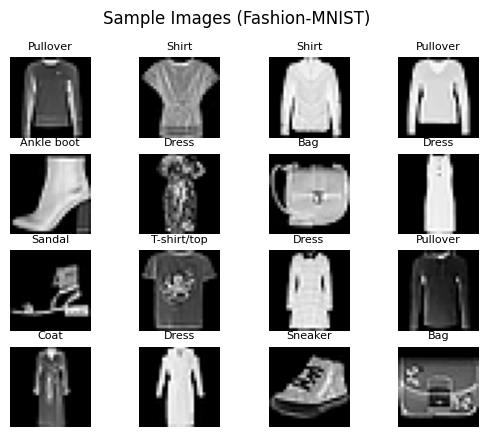

In [6]:
# Create a new figure for plotting
plt.figure()
# Loop through the first 16 images in the training set
for i in range(16):
    # Create a 4x4 grid of subplots
    plt.subplot(4, 4, i+1)
    # Display the image (squeeze removes single-dimensional entries like the channel dimension)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    # Set the title for each subplot with the class name
    plt.title(class_names[y_train[i]], fontsize=8)
    # Turn off the axis ticks and labels
    plt.axis("off")
# Set the main title for the entire figure
plt.suptitle("Sample Images (Fashion-MNIST)")
# Show the plot
plt.show()

In [7]:
# Define the Convolutional Neural Network (CNN) model using Keras Sequential API
model = keras.Sequential([
    # Input layer expects 28x28 grayscale images (1 channel)
    layers.Input(shape=(28, 28, 1)),
    # First convolutional layer with 32 filters, 3x3 kernel, ReLU activation, and 'same' padding
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    # Max pooling layer to reduce spatial dimensions
    layers.MaxPooling2D(),
    # Second convolutional layer with 64 filters, 3x3 kernel, ReLU activation, and 'same' padding
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    # Max pooling layer
    layers.MaxPooling2D(),
    # Flatten the 3D output to 1D for feeding into dense layers
    layers.Flatten(),
    # Dense (fully connected) layer with 128 units and ReLU activation
    layers.Dense(128, activation="relu"),
    # Dropout layer to prevent overfitting by randomly setting 30% of inputs to 0
    layers.Dropout(0.3),
    # Output dense layer with 10 units (for 10 classes) and softmax activation for probabilities
    layers.Dense(10, activation="softmax"),
])

# Compile the model with an optimizer, loss function, and metrics
model.compile(
    optimizer="adam", # Adam optimizer is a popular choice for deep learning
    loss="sparse_categorical_crossentropy", # Suitable for integer labels when classes are mutually exclusive
    metrics=["accuracy"] # Monitor accuracy during training
)

# Display a summary of the model architecture, including layer types, output shapes, and number of parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Define an EarlyStopping callback to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", # Monitor the validation loss
    patience=2,         # Stop if validation loss doesn't improve for 2 consecutive epochs
    restore_best_weights=True # Restore model weights from the epoch with the best validation loss
)

# Train the model using the training data and validate with the validation data
history = model.fit(
    X_train, y_train,              # Training features and labels
    validation_data=(X_val, y_val), # Validation features and labels
    epochs=12,                      # Maximum number of training epochs
    batch_size=128,                 # Number of samples per gradient update
    callbacks=[early_stop],         # Apply the EarlyStopping callback
    verbose=1                       # Display training progress for each epoch
)

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 64s 148ms/step - accuracy: 0.7104 - loss: 0.7970 - val_accuracy: 0.8678 - val_loss: 0.3499
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - accuracy: 0.8678 - loss: 0.3592 - val_accuracy: 0.8907 - val_loss: 0.2950
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 148ms/step - accuracy: 0.8908 - loss: 0.3045 - val_accuracy: 0.9008 - val_loss: 0.2639
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 152ms/step - accuracy: 0.9003 - loss: 0.2721 - val_accuracy: 0.9045 - val_loss: 0.2518
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 145ms/step - accuracy: 0.9083 - loss: 0.2463 - val_accuracy: 0.9112 - val_loss: 0.2386
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 149ms/step - accuracy: 0.9147 - loss: 0.2282 - val_accuracy: 0.9125 - val_loss: 0.2301
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 63s 149ms/step - accuracy: 0.9228 - loss: 0.2123 - val_accuracy: 0.9197 - val_loss: 0.2168
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 63s 149ms/step - accuracy: 0.9282 - loss: 0

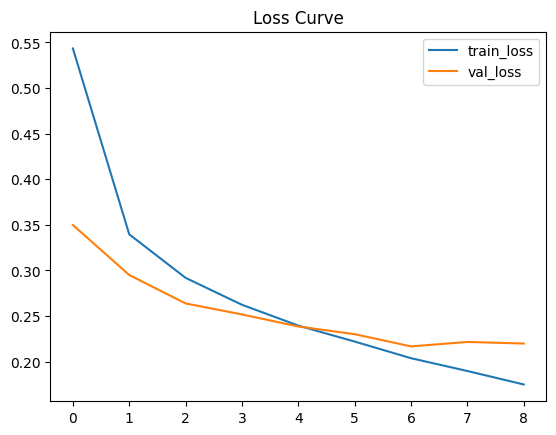

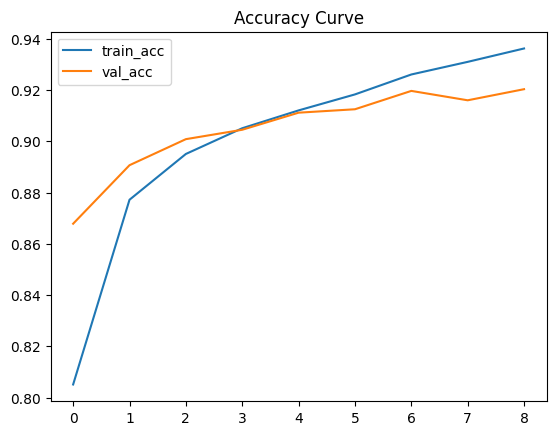

In [10]:
# Create a figure for the loss curve
plt.figure()
# Plot training loss
plt.plot(history.history["loss"], label="train_loss")
# Plot validation loss
plt.plot(history.history["val_loss"], label="val_loss")
# Display legend
plt.legend()
# Set plot title
plt.title("Loss Curve")
# Show the plot
plt.show()

# Create a figure for the accuracy curve
plt.figure()
# Plot training accuracy
plt.plot(history.history["accuracy"], label="train_acc")
# Plot validation accuracy
plt.plot(history.history["val_accuracy"], label="val_acc")
# Display legend
plt.legend()
# Set plot title
plt.title("Accuracy Curve")
# Show the plot
plt.show()

Test accuracy: 0.9121999740600586

Classification report:

              precision    recall  f1-score   support

 T-shirt/top     0.8400    0.8980    0.8681      1000
     Trouser     0.9879    0.9830    0.9855      1000
    Pullover     0.8566    0.8660    0.8613      1000
       Dress     0.9091    0.9200    0.9145      1000
        Coat     0.8349    0.8750    0.8545      1000
      Sandal     0.9869    0.9800    0.9834      1000
       Shirt     0.7854    0.6880    0.7335      1000
     Sneaker     0.9494    0.9750    0.9620      1000
         Bag     0.9919    0.9740    0.9828      1000
  Ankle boot     0.9757    0.9630    0.9693      1000

    accuracy                         0.9122     10000
   macro avg     0.9118    0.9122    0.9115     10000
weighted avg     0.9118    0.9122    0.9115     10000



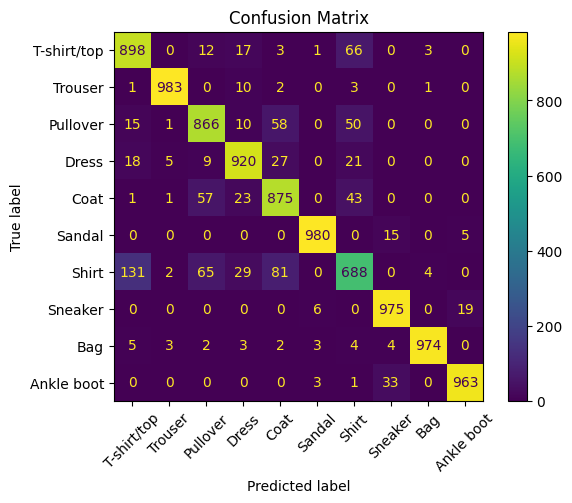

In [11]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
# Print the test accuracy
print("Test accuracy:", test_acc)

# Predict probabilities for the test set images
y_prob = model.predict(X_test, verbose=0)
# Get the predicted class label (index with highest probability) for each image
y_pred = np.argmax(y_prob, axis=1)

# Print the classification report, showing precision, recall, f1-score for each class
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Create a display object for the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
# Plot the confusion matrix with rotated x-axis labels
disp.plot(xticks_rotation=45)
# Set the title of the plot
plt.title("Confusion Matrix")
# Show the plot
plt.show()

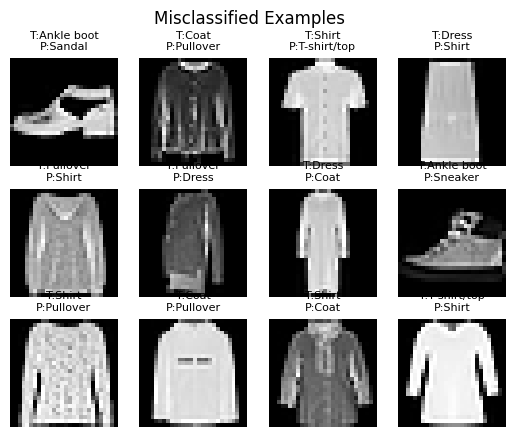

In [12]:
# Find the indices where the model's predictions do not match the true labels
wrong = np.where(y_pred != y_test)[0]

# Create a new figure to display misclassified examples
plt.figure()
# Iterate through the first 12 misclassified examples
for i, idx in enumerate(wrong[:12]):
    # Create a 3x4 grid of subplots
    plt.subplot(3, 4, i+1)
    # Display the misclassified image (squeeze removes single-dimensional entries)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    # Set the title to show True (T) and Predicted (P) labels
    plt.title(f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=8)
    # Turn off the axis ticks and labels
    plt.axis("off")
# Set the main title for the entire figure
plt.suptitle("Misclassified Examples")
# Show the plot
plt.show()